### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

### **Dataset Loading**

In [2]:
# Load your preprocessed dataset from Project 2
df = pd.read_csv('/content/sample_data/titanic_preprocessed.csv')

print(df.shape)
print(df.head())
print(df.columns)

(891, 13)
   Survived  Pclass       Age     SibSp     Parch      Fare  FamilySize  \
0         0       3 -0.565736  0.432793 -0.473674 -0.502445    0.059160   
1         1       1  0.663861  0.432793 -0.473674  0.786845    0.059160   
2         1       3 -0.258337 -0.474545 -0.473674 -0.488854   -0.560975   
3         1       1  0.433312  0.432793 -0.473674  0.420730    0.059160   
4         0       3  0.433312 -0.474545 -0.473674 -0.486337   -0.560975   

   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Title_encoded  
0       False      True       False       False        True              4  
1        True     False        True       False       False              3  
2        True     False       False       False        True              2  
3        True     False       False       False        True              3  
4       False      True       False       False        True              4  
Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
 

### **Define Features**

In [3]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"Survival rate in train: {y_train.mean():.3f}")
print(f"Survival rate in test: {y_test.mean():.3f}")

Train size: 712
Test size: 179
Survival rate in train: 0.376
Survival rate in test: 0.413


### **Baseline Model** (Default Parameters)

In [4]:
# Using Decision Tree as base model
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)

print("BASELINE MODEL (Default Parameters)")
print("-" * 40)
print(f"Accuracy:  {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall:    {recall_baseline:.4f}")
print(f"F1-score:  {f1_baseline:.4f}")
print(f"\nDefault parameters: {baseline_model.get_params()}")

BASELINE MODEL (Default Parameters)
----------------------------------------
Accuracy:  0.7765
Precision: 0.7297
Recall:    0.7297
F1-score:  0.7297

Default parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


### **Define Hyperparameter Grid**

In [5]:
# Hyperparameter grid for Decision Tree
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# For Randomized Search - wider distribution
param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, None],
    'min_samples_split': [2, 3, 5, 7, 10, 15, 20, 30],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 8, 10],
    'criterion': ['gini', 'entropy']
}

print("Grid Search space:")
print(f"max_depth: {param_grid['max_depth']}")
print(f"min_samples_split: {param_grid['min_samples_split']}")
print(f"min_samples_leaf: {param_grid['min_samples_leaf']}")
print(f"criterion: {param_grid['criterion']}")
print(f"\nTotal combinations: {len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['criterion'])}")

Grid Search space:
max_depth: [3, 5, 7, 10, None]
min_samples_split: [2, 5, 10, 20]
min_samples_leaf: [1, 2, 4, 8]
criterion: ['gini', 'entropy']

Total combinations: 160


### **Grid Search with Cross-Validation**

In [6]:
print("Running Grid Search...")
print("-" * 40)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters from Grid Search:")
print(grid_search.best_params_)
print(f"Best cross-validation F1 score: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test)

accuracy_grid = accuracy_score(y_test, y_pred_grid)
precision_grid = precision_score(y_test, y_pred_grid)
recall_grid = recall_score(y_test, y_pred_grid)
f1_grid = f1_score(y_test, y_pred_grid)

print(f"\nGrid Search Model - Test Set Performance:")
print(f"Accuracy:  {accuracy_grid:.4f}")
print(f"Precision: {precision_grid:.4f}")
print(f"Recall:    {recall_grid:.4f}")
print(f"F1-score:  {f1_grid:.4f}")

Running Grid Search...
----------------------------------------
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best parameters from Grid Search:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation F1 score: 0.7459

Grid Search Model - Test Set Performance:
Accuracy:  0.8156
Precision: 0.8060
Recall:    0.7297
F1-score:  0.7660


### **Randomized Search with Cross-Validation**

In [7]:
print("Running Randomized Search...")
print("-" * 40)

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters from Randomized Search:")
print(random_search.best_params_)
print(f"Best cross-validation F1 score: {random_search.best_score_:.4f}")

# Evaluate on test set
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)

accuracy_random = accuracy_score(y_test, y_pred_random)
precision_random = precision_score(y_test, y_pred_random)
recall_random = recall_score(y_test, y_pred_random)
f1_random = f1_score(y_test, y_pred_random)

print(f"\nRandomized Search Model - Test Set Performance:")
print(f"Accuracy:  {accuracy_random:.4f}")
print(f"Precision: {precision_random:.4f}")
print(f"Recall:    {recall_random:.4f}")
print(f"F1-score:  {f1_random:.4f}")

Running Randomized Search...
----------------------------------------
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters from Randomized Search:
{'min_samples_split': 3, 'min_samples_leaf': 6, 'max_depth': 6, 'criterion': 'entropy'}
Best cross-validation F1 score: 0.7442

Randomized Search Model - Test Set Performance:
Accuracy:  0.7765
Precision: 0.8400
Recall:    0.5676
F1-score:  0.6774


### **Performance Comparison MetricS**

In [8]:
results = pd.DataFrame({
    'Model': ['Default', 'Grid Search', 'Randomized Search'],
    'Accuracy': [accuracy_baseline, accuracy_grid, accuracy_random],
    'Precision': [precision_baseline, precision_grid, precision_random],
    'Recall': [recall_baseline, recall_grid, recall_random],
    'F1-Score': [f1_baseline, f1_grid, f1_random]
})

print("PERFORMANCE COMPARISON")
print("-" * 60)
print(results.to_string(index=False))

print("\nOPTIMAL HYPERPARAMETERS FOUND")
print("-" * 60)
print(f"Default model: {baseline_model.get_params()}")
print(f"\nGrid Search best: {grid_search.best_params_}")
print(f"\nRandomized Search best: {random_search.best_params_}")

PERFORMANCE COMPARISON
------------------------------------------------------------
            Model  Accuracy  Precision   Recall  F1-Score
          Default  0.776536    0.72973 0.729730  0.729730
      Grid Search  0.815642    0.80597 0.729730  0.765957
Randomized Search  0.776536    0.84000 0.567568  0.677419

OPTIMAL HYPERPARAMETERS FOUND
------------------------------------------------------------
Default model: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Grid Search best: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Randomized Search best: {'min_samples_split': 3, 'min_samples_leaf': 6, 'max_depth': 6, 'criterion': 'entropy'}


### **Improvement Analysis**

In [9]:
print("IMPROVEMENT ANALYSIS")
print("-" * 60)

f1_improvement_grid = ((f1_grid - f1_baseline) / f1_baseline) * 100
f1_improvement_random = ((f1_random - f1_baseline) / f1_baseline) * 100

print(f"Grid Search F1 improvement: {f1_improvement_grid:+.2f}%")
print(f"Randomized Search F1 improvement: {f1_improvement_random:+.2f}%")

if f1_grid > f1_random:
    print(f"\nGrid Search performed better with F1 = {f1_grid:.4f}")
elif f1_random > f1_grid:
    print(f"\nRandomized Search performed better with F1 = {f1_random:.4f}")
else:
    print(f"\nBoth methods achieved same F1 score = {f1_grid:.4f}")

print(f"\nBest overall model: {'Grid Search' if f1_grid >= f1_random else 'Randomized Search'}")
print(f"Best overall F1 score: {max(f1_grid, f1_random):.4f}")

IMPROVEMENT ANALYSIS
------------------------------------------------------------
Grid Search F1 improvement: +4.96%
Randomized Search F1 improvement: -7.17%

Grid Search performed better with F1 = 0.7660

Best overall model: Grid Search
Best overall F1 score: 0.7660


### **Visual comparison**

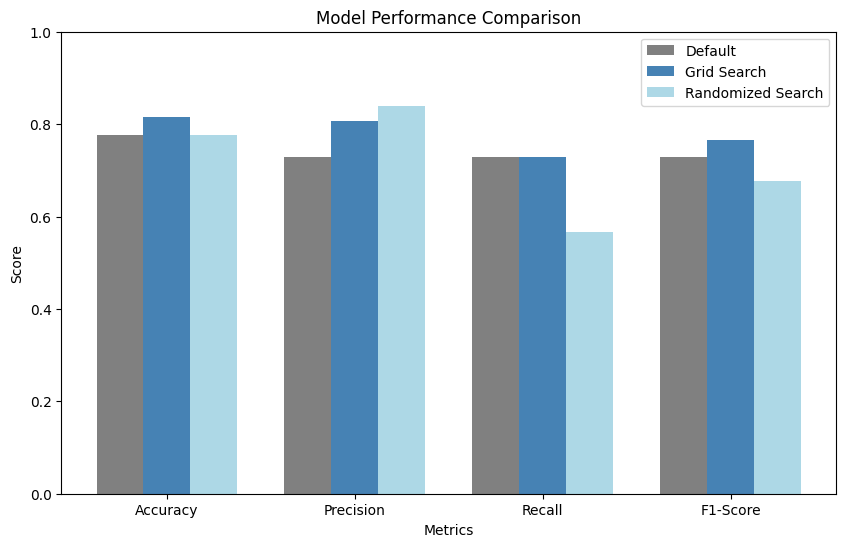

Comparison chart saved as 'hyperparameter_comparison.png'


In [10]:
# Bar plot comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
default_scores = [accuracy_baseline, precision_baseline, recall_baseline, f1_baseline]
grid_scores = [accuracy_grid, precision_grid, recall_grid, f1_grid]
random_scores = [accuracy_random, precision_random, recall_random, f1_random]

x = range(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar([i - width for i in x], default_scores, width, label='Default', color='gray')
plt.bar(x, grid_scores, width, label='Grid Search', color='steelblue')
plt.bar([i + width for i in x], random_scores, width, label='Randomized Search', color='lightblue')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1)
plt.savefig('hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Comparison chart saved as 'hyperparameter_comparison.png'")